<a href="https://colab.research.google.com/github/viktorbrojs-sys/BH_DS_Pro/blob/main/HW_1/ai4i2020_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Предсказание отказов оборудования

**Датасет:** AI4I 2020 Predictive Maintenance Dataset  
**Задача:** Бинарная классификация (Machine failure: 0/1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)
import joblib
from IPython.display import display

sns.set_style('whitegrid')
%matplotlib inline

## 1. Загрузка данных

In [2]:
df = pd.read_csv('ai4i2020.csv')
print("Датасет загружен. Размер:", df.shape)

Датасет загружен. Размер: (10000, 14)


## 2. Первичный осмотр данных

In [3]:
print("\nИнформация о данных:")
df.info()
print("\nПервые 5 строк:")
display(df.head())
print("\nПроверка пропусков:")
print(df.isnull().sum())


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Проверка пропусков:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


## 3. Анализ целевой переменной

In [4]:
print("\nРаспределение отказов (Machine failure):")
failure_counts = df['Machine failure'].value_counts()
print(failure_counts)
print(f"Доля отказов: {failure_counts[1] / len(df) * 100:.2f}%")


Распределение отказов (Machine failure):
Machine failure
0    9661
1     339
Name: count, dtype: int64
Доля отказов: 3.39%


## 4. Визуализация распределений признаков

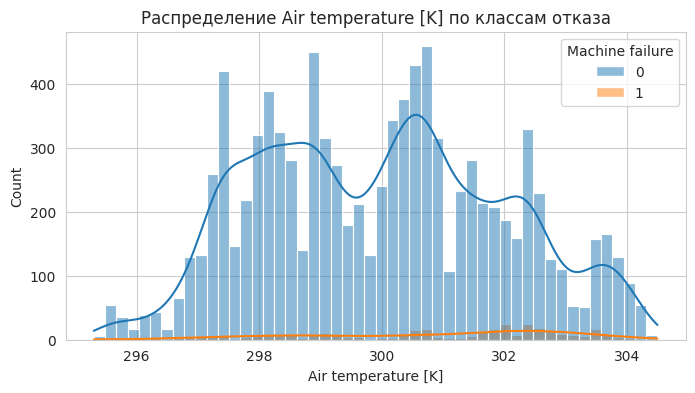

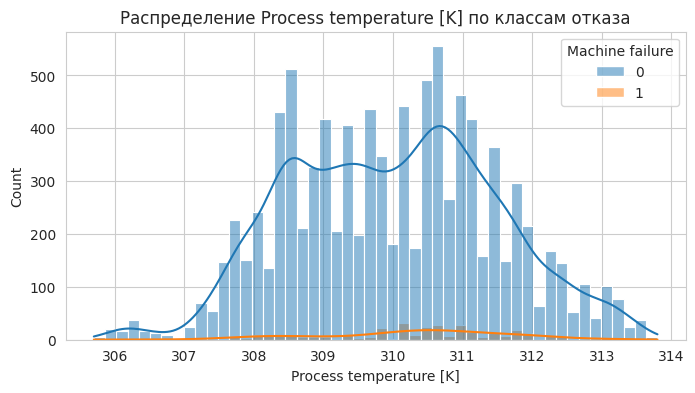

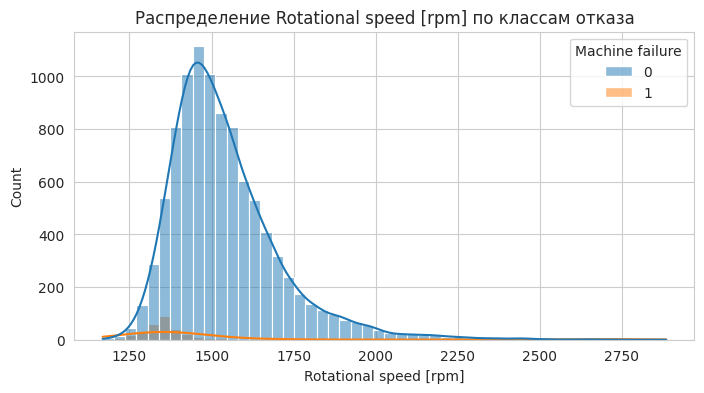

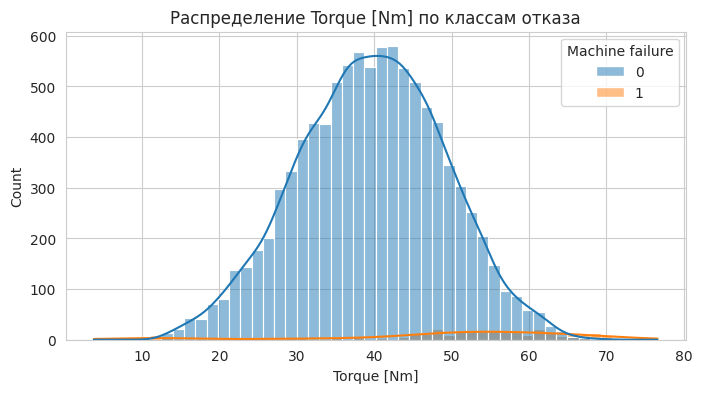

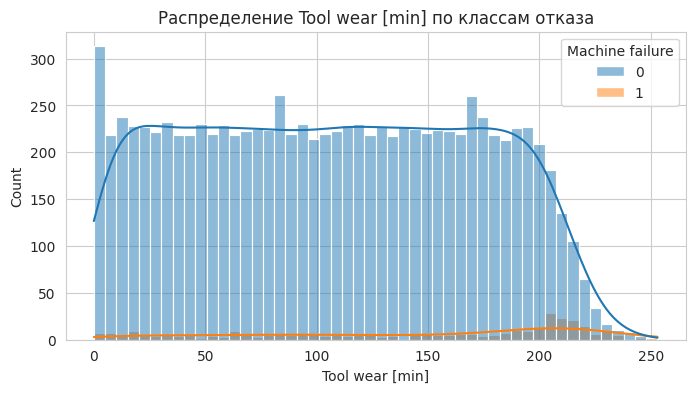

In [5]:
numeric_features = ['Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=feature, hue='Machine failure', bins=50, alpha=0.5, kde=True)
    plt.title(f'Распределение {feature} по классам отказа')
    plt.show()

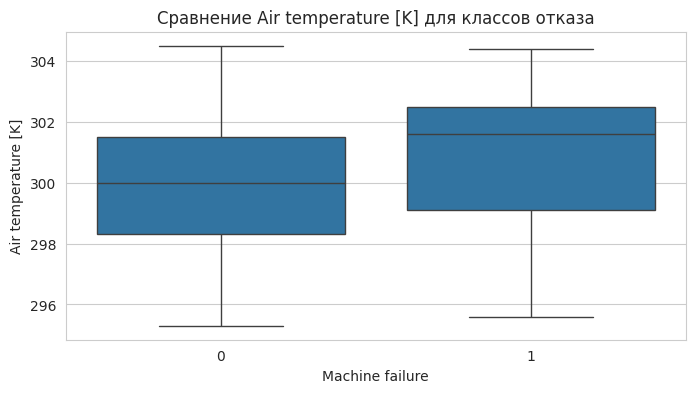

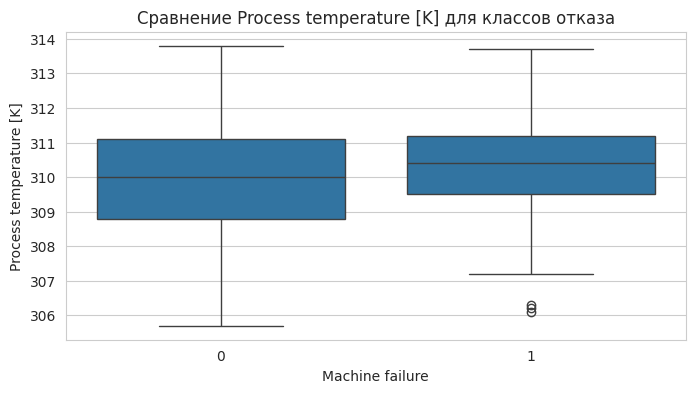

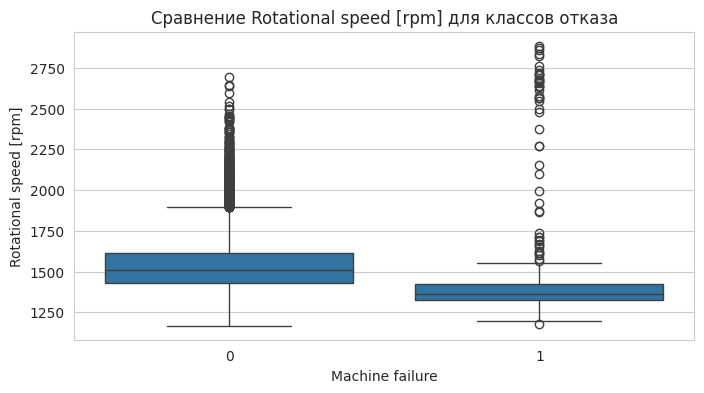

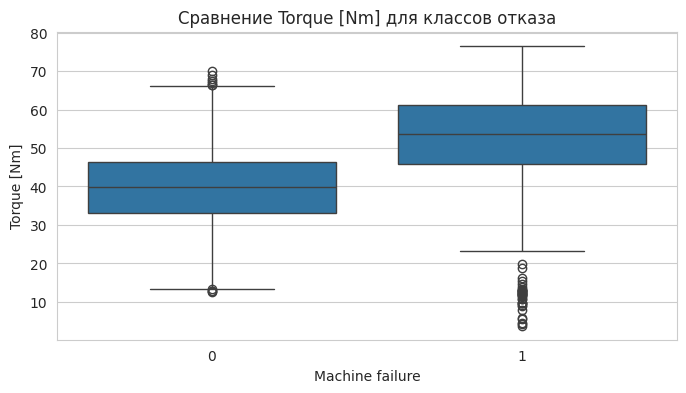

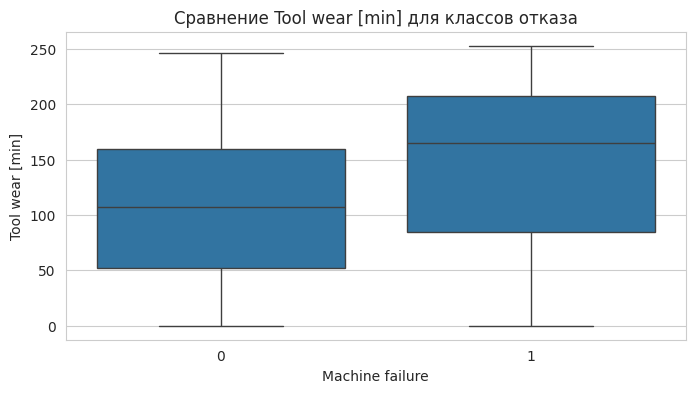

In [6]:
for feature in numeric_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x='Machine failure', y=feature)
    plt.title(f'Сравнение {feature} для классов отказа')
    plt.show()

## 5. Корреляционная матрица

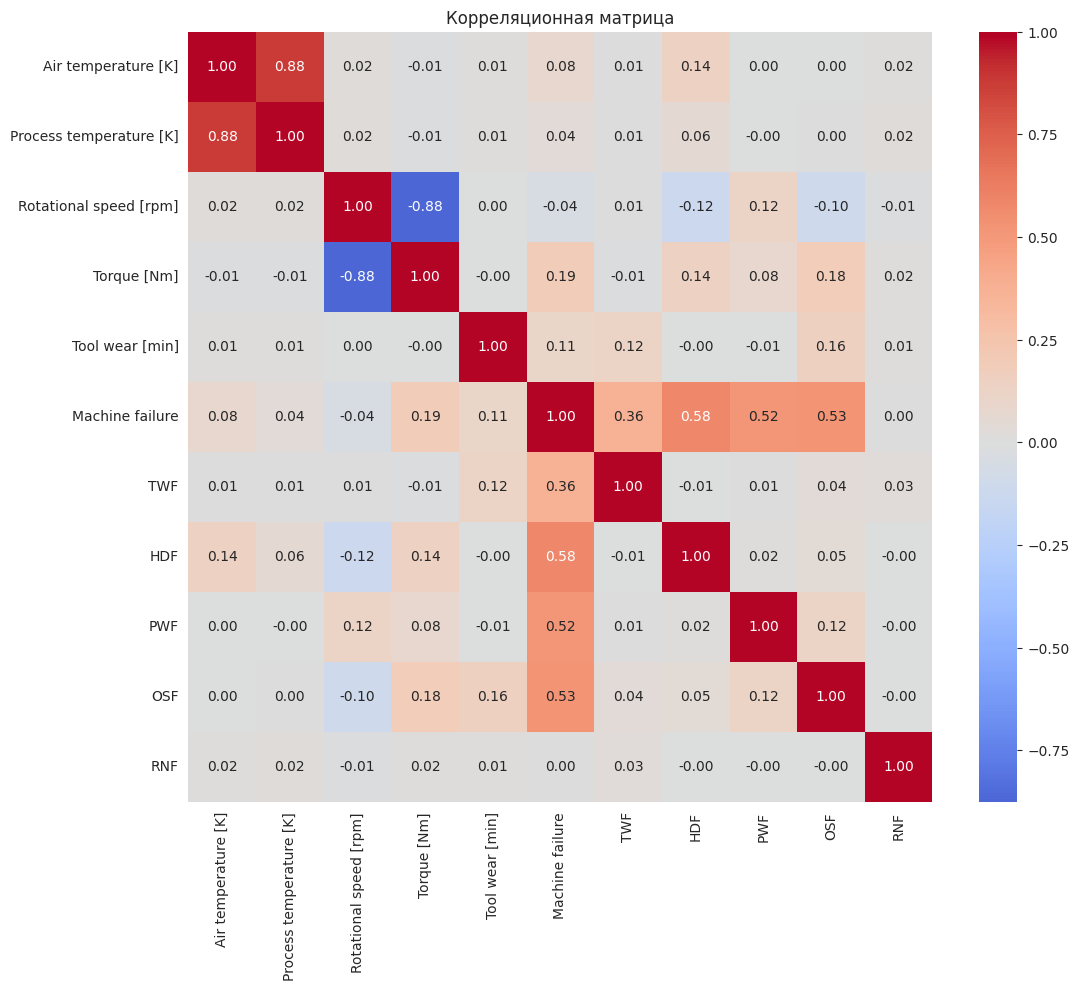

In [7]:
corr_features = numeric_features + ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
corr_matrix = df[corr_features].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляционная матрица')
plt.show()

## 6. Feature Engineering

In [8]:
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power'] = df['Rotational speed [rpm]'] * df['Torque [Nm]']
df['Stress'] = df['Tool wear [min]'] * df['Torque [Nm]']
print("Добавлены новые признаки. Теперь колонок:", df.shape[1])

Добавлены новые признаки. Теперь колонок: 17


## 7. Предобработка данных

In [9]:
# Удаление лишних колонок
cols_to_drop = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df.drop(columns=cols_to_drop, inplace=True)
print("Оставшиеся колонки:", df.columns.tolist())

# Кодирование категориального признака Type
type_mapping = {'L': 0, 'M': 1, 'H': 2}
df['Type_encoded'] = df['Type'].map(type_mapping)
df.drop(columns=['Type'], inplace=True)
print("Кодирование Type выполнено.")

Оставшиеся колонки: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Temp_diff', 'Power', 'Stress']
Кодирование Type выполнено.


## 8. Подготовка данных для моделирования

In [10]:
# Разделение на признаки и целевую переменную
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']
print("Размер X:", X.shape)
print("Размер y:", y.shape)

# Разделение на train/test (стратифицированное)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Обучающая выборка: {X_train.shape}, отказов: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Тестовая выборка: {X_test.shape}, отказов: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

Размер X: (10000, 9)
Размер y: (10000,)
Обучающая выборка: (8000, 9), отказов: 271 (3.39%)
Тестовая выборка: (2000, 9), отказов: 68 (3.40%)


In [11]:
# Масштабирование числовых признаков
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
            'Temp_diff', 'Power', 'Stress']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])
print("Масштабирование выполнено.")

Масштабирование выполнено.


## 9. Обучение моделей

In [12]:
# Логистическая регрессия
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': ['balanced', None],
    'max_iter': [1000]
}
lr = LogisticRegression(random_state=42)
lr_grid = GridSearchCV(lr, lr_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1, verbose=1)
print("Обучение логистической регрессии...")
lr_grid.fit(X_train_scaled, y_train)
print("Лучшие параметры (LR):", lr_grid.best_params_)
print("Лучший F1 на CV: {:.4f}".format(lr_grid.best_score_))

Обучение логистической регрессии...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры (LR): {'C': 10, 'class_weight': None, 'max_iter': 1000}
Лучший F1 на CV: 0.3676


In [13]:
# Случайный лес
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'class_weight': ['balanced', None]
}
rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1, verbose=1)
print("\nОбучение случайного леса...")
rf_grid.fit(X_train_scaled, y_train)
print("Лучшие параметры (RF):", rf_grid.best_params_)
print("Лучший F1 на CV: {:.4f}".format(rf_grid.best_score_))


Обучение случайного леса...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лучшие параметры (RF): {'class_weight': None, 'max_depth': None, 'n_estimators': 200}
Лучший F1 на CV: 0.8921


## 10. Оценка на тестовой выборке

In [14]:
models = {
    'Logistic Regression': lr_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc_auc
    })

    cm = confusion_matrix(y_test, y_pred)
    print(f"\n{name}")
    print(f"Матрица ошибок:\n{cm}")
    print(classification_report(y_test, y_pred, digits=4))

results_df = pd.DataFrame(results)
print("\nСводная таблица результатов:")
display(results_df)


Logistic Regression
Матрица ошибок:
[[1923    9]
 [  54   14]]
              precision    recall  f1-score   support

           0     0.9727    0.9953    0.9839      1932
           1     0.6087    0.2059    0.3077        68

    accuracy                         0.9685      2000
   macro avg     0.7907    0.6006    0.6458      2000
weighted avg     0.9603    0.9685    0.9609      2000


Random Forest
Матрица ошибок:
[[1930    2]
 [  13   55]]
              precision    recall  f1-score   support

           0     0.9933    0.9990    0.9961      1932
           1     0.9649    0.8088    0.8800        68

    accuracy                         0.9925      2000
   macro avg     0.9791    0.9039    0.9381      2000
weighted avg     0.9923    0.9925    0.9922      2000


Сводная таблица результатов:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9685,0.608696,0.205882,0.307692,0.930726
1,Random Forest,0.9925,0.964912,0.808824,0.880000,0.973888


## 11. ROC-кривые

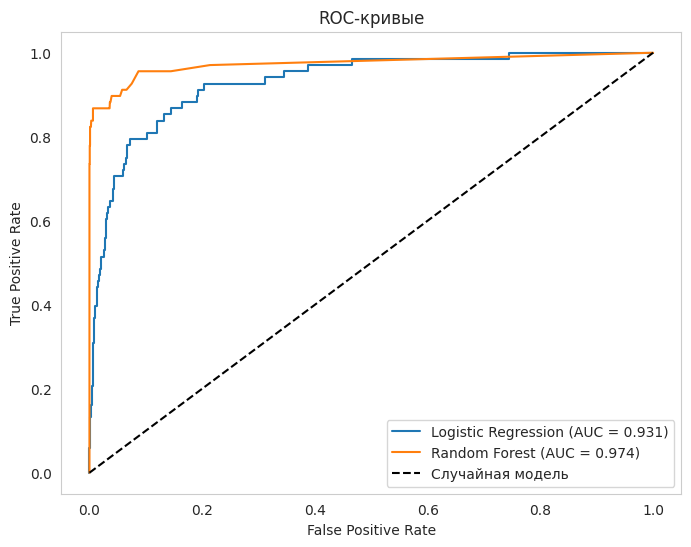

In [15]:
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайная модель')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые')
plt.legend()
plt.grid()
plt.show()

## 12. Важность признаков (Random Forest)

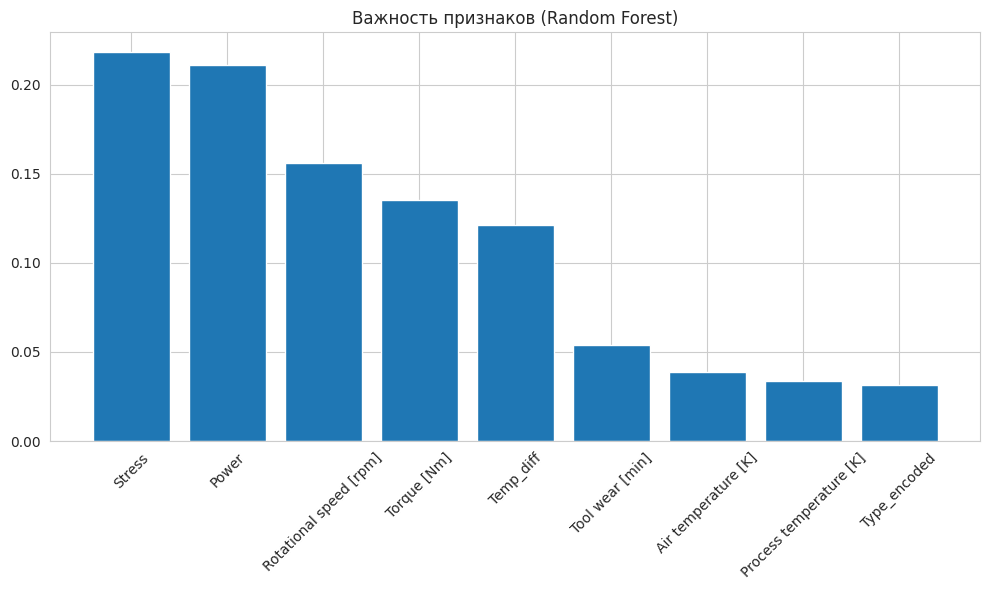

Рейтинг признаков:
Stress: 0.2184
Power: 0.2112
Rotational speed [rpm]: 0.1562
Torque [Nm]: 0.1351
Temp_diff: 0.1210
Tool wear [min]: 0.0539
Air temperature [K]: 0.0388
Process temperature [K]: 0.0339
Type_encoded: 0.0315


In [16]:
feature_names = X_train.columns
importances = rf_grid.best_estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Важность признаков (Random Forest)")
plt.bar(range(len(importances)), importances[indices], align='center')
plt.xticks(range(len(importances)), feature_names[indices], rotation=45)
plt.tight_layout()
plt.show()

print("Рейтинг признаков:")
for i in indices:
    print(f"{feature_names[i]}: {importances[i]:.4f}")

## 13. Сохранение лучшей модели

In [17]:
best_model = rf_grid.best_estimator_
joblib.dump(best_model, 'best_model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Модель сохранена: best_model_rf.pkl")
print("Скейлер сохранён: scaler.pkl")

Модель сохранена: best_model_rf.pkl
Скейлер сохранён: scaler.pkl
